# **ANN-Based Classification of Iris Using Shallow MLP**

**Domain:** Biology / Agriculture
**Dataset:** Iris Dataset  
**Source:** UCI Machine Learning Repository  
**Problem Type:** Multiclass Classification  
**Neural Network:** Shallow Multi-Layer Perceptron (MLP)  
**Optimization:** Mini-Batch Gradient Descent

**Project Overview**

This project develops an Artificial Neural Network based on a Shallow
Multi-Layer Perceptron to classify Iris flowers into three species using
four numerical flower measurements.

The project includes data preprocessing, baseline and proposed ANN
architectures, controlled hyperparameter experiments, final evaluation,
error analysis, and interactive prediction on user-provided measurements.

**Step 1: Loading the Iris Dataset**

In [157]:
#Install UCI dataset library
!pip install ucimlrepo

In [158]:
#Import and load the dataset
from ucimlrepo import fetch_ucirepo

iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets

In [159]:
#Check the dataset
print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [160]:
#Check dimensions
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150, 1)


In [161]:
#Check class distribution
print(y.value_counts())

class          
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


**Step 2: Understand and preprocess the dataset.**

In [162]:
print("Dataset Information:")
print(X.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


In [163]:
print("\nStatistical Summary:")
display(X.describe())


Statistical Summary:


,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [164]:
print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
sepal length    0
sepal width     0
petal length    0
petal width     0
dtype: int64

Missing values in target:
class    0
dtype: int64


In [165]:
print("Unique classes:")
print(y.iloc[:, 0].unique())

Unique classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [166]:
#Encode the target
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y.iloc[:, 0])

print("Encoded labels:")
print(y_encoded[:10])

print("\nClass mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "→", class_name)

Encoded labels:
[0 0 0 0 0 0 0 0 0 0]

Class mapping:
0 → Iris-setosa
1 → Iris-versicolor
2 → Iris-virginica


In [167]:
#train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [168]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train_scaled[:5])

print("\nMean of scaled training features:")
print(X_train_scaled.mean(axis=0))

print("\nStandard deviation:")
print(X_train_scaled.std(axis=0))

First 5 scaled training samples:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]

Mean of scaled training features:
[-1.36927506e-16  4.55191440e-16 -9.06682137e-17  5.36607795e-17]

Standard deviation:
[1. 1. 1. 1.]


**Step 3 — Build the Baseline ANN**

In [169]:
import numpy as np
X_train_np = np.array(X_train_scaled)
X_test_np = np.array(X_test_scaled)

y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

print("X_train:", X_train_np.shape)
print("y_train:", y_train_np.shape)
print("X_test:", X_test_np.shape)
print("y_test:", y_test_np.shape)

X_train: (120, 4)
y_train: (120,)
X_test: (30, 4)
y_test: (30,)


**3.1 Activation Functions**

In [170]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

**3.2 One-Hot-Encoding**

In [171]:
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

y_train_onehot = one_hot_encode(y_train_np, 3)

print(y_train_onehot[:5])

[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


**3.3 Initialize the Network**

In [172]:
np.random.seed(42)

input_size = 4
hidden_size = 4
output_size = 3

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (4, 4)
b1 shape: (1, 4)
W2 shape: (4, 3)
b2 shape: (1, 3)


**3.4 Forward Propagation**

In [173]:
def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

**3.5 Loss Function**

In [174]:
def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]

    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y_true * np.log(y_pred)) / m

    return loss

**3.6 Backpropagation**

In [175]:
def backward_propagation(X, y_true, Z1, A1, A2, W2):
    m = X.shape[0]

    # Output layer gradient
    dZ2 = A2 - y_true

    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer gradient
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

**3.7 Mini-Batch Gradient Descent**

In [176]:
def train_model(
    X_train,
    y_train,
    input_size,
    hidden_size,
    output_size,
    learning_rate=0.01,
    batch_size=16,
    epochs=100
):
    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))

    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    loss_history = []

    n_samples = X_train.shape[0]

    for epoch in range(epochs):

        # Shuffle training data
        indices = np.random.permutation(n_samples)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        epoch_loss = 0

        # Mini-batch training
        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Forward propagation
            Z1, A1, Z2, A2 = forward_propagation(
                X_batch, W1, b1, W2, b2
            )

            # Calculate loss
            loss = cross_entropy_loss(y_batch, A2)
            epoch_loss += loss * X_batch.shape[0]

            # Backpropagation
            dW1, db1, dW2, db2 = backward_propagation(
                X_batch,
                y_batch,
                Z1,
                A1,
                A2,
                W2
            )

            # Update weights
            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1

            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

        # Average epoch loss
        epoch_loss /= n_samples
        loss_history.append(epoch_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1}/{epochs}, "
                f"Loss: {epoch_loss:.4f}"
            )

    return W1, b1, W2, b2, loss_history

**3.8 Train the Baseline Model**

In [177]:
W1_baseline, b1_baseline, W2_baseline, b2_baseline, loss_history_baseline = train_model(
    X_train_np,
    y_train_onehot,
    input_size=4,
    hidden_size=4,
    output_size=3,
    learning_rate=0.01,
    batch_size=16,
    epochs=100
)

Epoch 10/100, Loss: 1.0986
Epoch 20/100, Loss: 1.0981
Epoch 30/100, Loss: 1.0968
Epoch 40/100, Loss: 1.0934
Epoch 50/100, Loss: 1.0840
Epoch 60/100, Loss: 1.0592
Epoch 70/100, Loss: 1.0041
Epoch 80/100, Loss: 0.9100
Epoch 90/100, Loss: 0.8099
Epoch 100/100, Loss: 0.7373


**3.9 Plot Training Loss**

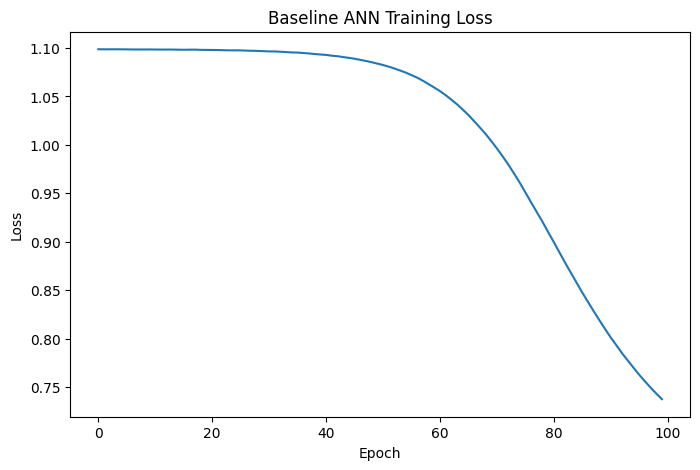

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history_baseline)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline ANN Training Loss")

plt.show()

**3.10 Make predictions**

In [179]:
def predict(X, W1, b1, W2, b2):
    _, _, _, probabilities = forward_propagation(
        X, W1, b1, W2, b2
    )

    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities

In [180]:
y_pred_baseline, y_prob_baseline = predict(
    X_test_np,
    W1_baseline,
    b1_baseline,
    W2_baseline,
    b2_baseline
)

print("Predicted classes:")
print(y_pred_baseline)

print("\nActual classes:")
print(y_test_np)

Predicted classes:
[0 2 0 0 0 2 0 0 2 2 2 2 2 2 0 0 0 2 2 2 0 2 2 2 2 2 2 0 2 0]

Actual classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


**3.11 Calculate Accuracy**

In [181]:
from sklearn.metrics import accuracy_score

accuracy_baseline = accuracy_score(
    y_test_np,
    y_pred_baseline
)

print(f"Baseline Accuracy: {accuracy_baseline:.4f}")

Baseline Accuracy: 0.6667


**3.12 Precision, Recall and F1-score**

In [182]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_baseline = precision_score(
    y_test_np,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

recall_baseline = recall_score(
    y_test_np,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

f1_baseline = f1_score(
    y_test_np,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

print(f"Baseline Precision: {precision_baseline:.4f}")
print(f"Baseline Recall:    {recall_baseline:.4f}")
print(f"Baseline F1-score:  {f1_baseline:.4f}")

Baseline Precision: 0.4630
Baseline Recall:    0.6667
Baseline F1-score:  0.5411


**3.13 Classification Report**

In [183]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_np,
        y_pred_baseline,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       0.83      1.00      0.91        10
Iris-versicolor       0.00      0.00      0.00        10
 Iris-virginica       0.56      1.00      0.71        10

       accuracy                           0.67        30
      macro avg       0.46      0.67      0.54        30
   weighted avg       0.46      0.67      0.54        30



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**3.14 Confusion Matrix**

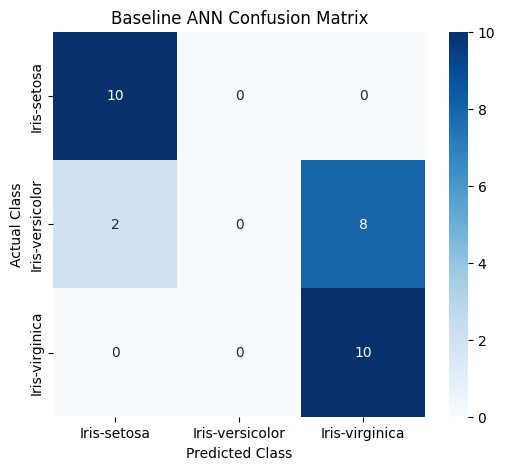

In [184]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_baseline = confusion_matrix(
    y_test_np,
    y_pred_baseline
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Baseline ANN Confusion Matrix")

plt.show()

**3.15 Store Baseline Results**

In [185]:
baseline_results = {
    "Model": "Baseline MLP",
    "Hidden Neurons": 4,
    "Learning Rate": 0.01,
    "Batch Size": 16,
    "Epochs": 100,
    "Accuracy": accuracy_baseline,
    "Precision": precision_baseline,
    "Recall": recall_baseline,
    "F1-Score": f1_baseline
}

baseline_results

{'Model': 'Baseline MLP',
 'Hidden Neurons': 4,
 'Learning Rate': 0.01,
 'Batch Size': 16,
 'Epochs': 100,
 'Accuracy': 0.6666666666666666,
 'Precision': 0.46296296296296297,
 'Recall': 0.6666666666666666,
 'F1-Score': 0.5411255411255411}

**Step 4 — Proposed Architecture**

In [186]:
#train proposed mlp
W1_proposed, b1_proposed, W2_proposed, b2_proposed, loss_history_proposed = train_model(
    X_train_np,
    y_train_onehot,
    input_size=4,
    hidden_size=8,
    output_size=3,
    learning_rate=0.01,
    batch_size=16,
    epochs=100
)

Epoch 10/100, Loss: 1.0987
Epoch 20/100, Loss: 1.0986
Epoch 30/100, Loss: 1.0981
Epoch 40/100, Loss: 1.0974
Epoch 50/100, Loss: 1.0949
Epoch 60/100, Loss: 1.0890
Epoch 70/100, Loss: 1.0735
Epoch 80/100, Loss: 1.0351
Epoch 90/100, Loss: 0.9555
Epoch 100/100, Loss: 0.8382


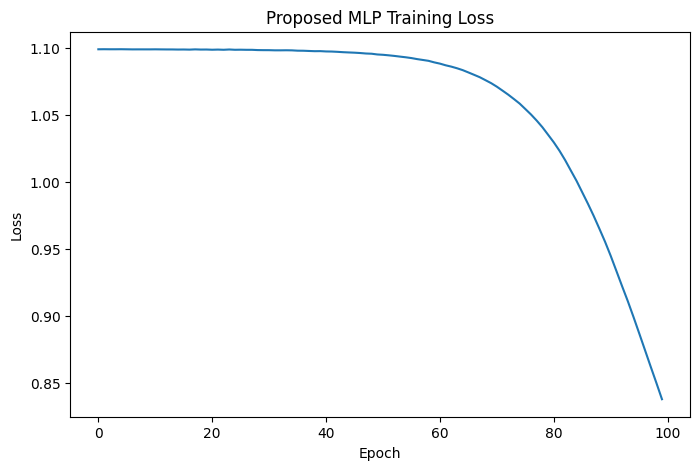

In [187]:
#plot proposed model loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history_proposed)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Proposed MLP Training Loss")

plt.show()

In [188]:
#test predictions
y_pred_proposed, y_prob_proposed = predict(
    X_test_np,
    W1_proposed,
    b1_proposed,
    W2_proposed,
    b2_proposed
)

print("Predicted classes:")
print(y_pred_proposed)

print("\nActual classes:")
print(y_test_np)

Predicted classes:
[0 2 0 0 0 2 0 0 2 2 2 2 2 2 0 0 0 2 2 2 0 2 2 2 2 2 2 0 2 0]

Actual classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [189]:
#evaluate proposed model
accuracy_proposed = accuracy_score(
    y_test_np,
    y_pred_proposed
)

precision_proposed = precision_score(
    y_test_np,
    y_pred_proposed,
    average="weighted",
    zero_division=0
)

recall_proposed = recall_score(
    y_test_np,
    y_pred_proposed,
    average="weighted",
    zero_division=0
)

f1_proposed = f1_score(
    y_test_np,
    y_pred_proposed,
    average="weighted",
    zero_division=0
)

print(f"Proposed Accuracy:  {accuracy_proposed:.4f}")
print(f"Proposed Precision: {precision_proposed:.4f}")
print(f"Proposed Recall:    {recall_proposed:.4f}")
print(f"Proposed F1-score:  {f1_proposed:.4f}")

Proposed Accuracy:  0.6667
Proposed Precision: 0.4630
Proposed Recall:    0.6667
Proposed F1-score:  0.5411


In [190]:
#proposed classification report
print(
    classification_report(
        y_test_np,
        y_pred_proposed,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       0.83      1.00      0.91        10
Iris-versicolor       0.00      0.00      0.00        10
 Iris-virginica       0.56      1.00      0.71        10

       accuracy                           0.67        30
      macro avg       0.46      0.67      0.54        30
   weighted avg       0.46      0.67      0.54        30



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


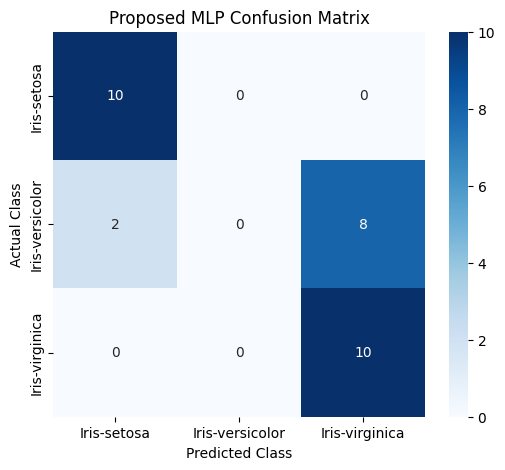

In [191]:
#proposed confusion matrix
cm_proposed = confusion_matrix(
    y_test_np,
    y_pred_proposed
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_proposed,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Proposed MLP Confusion Matrix")

plt.show()

In [192]:
#store proposed results
proposed_results = {
    "Model": "Proposed MLP",
    "Hidden Neurons": 8,
    "Learning Rate": 0.01,
    "Batch Size": 16,
    "Epochs": 100,
    "Accuracy": accuracy_proposed,
    "Precision": precision_proposed,
    "Recall": recall_proposed,
    "F1-Score": f1_proposed
}

proposed_results

{'Model': 'Proposed MLP',
 'Hidden Neurons': 8,
 'Learning Rate': 0.01,
 'Batch Size': 16,
 'Epochs': 100,
 'Accuracy': 0.6666666666666666,
 'Precision': 0.46296296296296297,
 'Recall': 0.6666666666666666,
 'F1-Score': 0.5411255411255411}

In [193]:
#compare baseline vs proposed
import pandas as pd

comparison = pd.DataFrame([
    baseline_results,
    proposed_results
])

display(comparison)

,Model,Hidden Neurons,Learning Rate,Batch Size,Epochs,Accuracy,Precision,Recall,F1-Score
0,Baseline MLP,4,0.01,16,100,0.666667,0.462963,0.666667,0.541126
1,Proposed MLP,8,0.01,16,100,0.666667,0.462963,0.666667,0.541126


**Step 5 — Learning Rate Variation**

In [194]:
#create helper function for evaluation
def evaluate_model(X_test, y_test, W1, b1, W2, b2):
    y_pred, _ = predict(
        X_test,
        W1,
        b1,
        W2,
        b2
    )

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1

In [195]:
#learning rate experiments
learning_rates = [0.001, 0.01, 0.1]

learning_rate_results = []

for lr in learning_rates:

    print(f"\nTraining with learning rate = {lr}")

    W1_lr, b1_lr, W2_lr, b2_lr, loss_lr = train_model(
        X_train_np,
        y_train_onehot,
        input_size=4,
        hidden_size=8,
        output_size=3,
        learning_rate=lr,
        batch_size=16,
        epochs=100
    )

    accuracy, precision, recall, f1 = evaluate_model(
        X_test_np,
        y_test_np,
        W1_lr,
        b1_lr,
        W2_lr,
        b2_lr
    )

    learning_rate_results.append({
        "Learning Rate": lr,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })


Training with learning rate = 0.001
Epoch 10/100, Loss: 1.0987
Epoch 20/100, Loss: 1.0987
Epoch 30/100, Loss: 1.0986
Epoch 40/100, Loss: 1.0986
Epoch 50/100, Loss: 1.0986
Epoch 60/100, Loss: 1.0986
Epoch 70/100, Loss: 1.0986
Epoch 80/100, Loss: 1.0986
Epoch 90/100, Loss: 1.0986
Epoch 100/100, Loss: 1.0985

Training with learning rate = 0.01
Epoch 10/100, Loss: 1.0987
Epoch 20/100, Loss: 1.0986
Epoch 30/100, Loss: 1.0981
Epoch 40/100, Loss: 1.0974
Epoch 50/100, Loss: 1.0949
Epoch 60/100, Loss: 1.0890
Epoch 70/100, Loss: 1.0735
Epoch 80/100, Loss: 1.0351
Epoch 90/100, Loss: 0.9555
Epoch 100/100, Loss: 0.8382

Training with learning rate = 0.1
Epoch 10/100, Loss: 0.9231
Epoch 20/100, Loss: 0.3605
Epoch 30/100, Loss: 0.2329
Epoch 40/100, Loss: 0.1646
Epoch 50/100, Loss: 0.1222
Epoch 60/100, Loss: 0.0982
Epoch 70/100, Loss: 0.0838
Epoch 80/100, Loss: 0.0773
Epoch 90/100, Loss: 0.0715
Epoch 100/100, Loss: 0.0664


In [196]:
lr_results_df = pd.DataFrame(learning_rate_results)

display(lr_results_df)

,Learning Rate,Accuracy,Precision,Recall,F1-Score
0,0.001,0.333333,0.111111,0.333333,0.166667
1,0.010,0.666667,0.462963,0.666667,0.541126
2,0.100,0.966667,0.969697,0.966667,0.966583


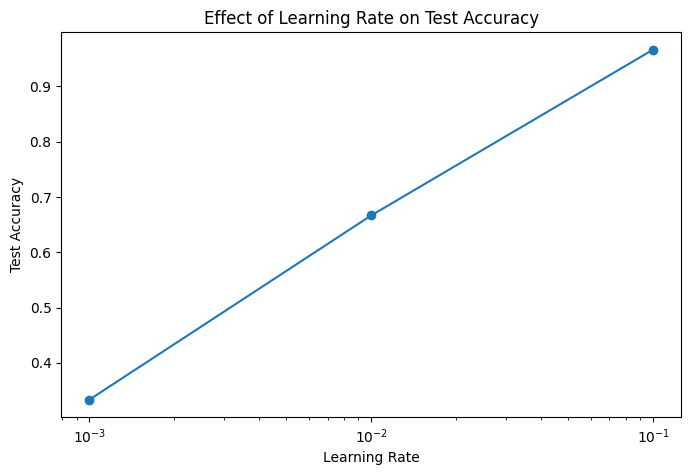

In [197]:
#plot learning-rate comparison
plt.figure(figsize=(8, 5))

plt.plot(
    lr_results_df["Learning Rate"],
    lr_results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Effect of Learning Rate on Test Accuracy")
plt.xscale("log")

plt.show()

**Step 6 — Batch Size Variation**

In [198]:
batch_sizes = [8, 16, 32]

batch_size_results = []

for batch_size in batch_sizes:

    print(f"\nTraining with batch size = {batch_size}")

    W1_bs, b1_bs, W2_bs, b2_bs, loss_bs = train_model(
        X_train_np,
        y_train_onehot,
        input_size=4,
        hidden_size=8,
        output_size=3,
        learning_rate=0.01,
        batch_size=batch_size,
        epochs=100
    )

    accuracy, precision, recall, f1 = evaluate_model(
        X_test_np,
        y_test_np,
        W1_bs,
        b1_bs,
        W2_bs,
        b2_bs
    )

    batch_size_results.append({
        "Batch Size": batch_size,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })


Training with batch size = 8
Epoch 10/100, Loss: 1.0988
Epoch 20/100, Loss: 1.0978
Epoch 30/100, Loss: 1.0926
Epoch 40/100, Loss: 1.0609
Epoch 50/100, Loss: 0.9206
Epoch 60/100, Loss: 0.7039
Epoch 70/100, Loss: 0.5602
Epoch 80/100, Loss: 0.4731
Epoch 90/100, Loss: 0.4154
Epoch 100/100, Loss: 0.3721

Training with batch size = 16
Epoch 10/100, Loss: 1.0987
Epoch 20/100, Loss: 1.0986
Epoch 30/100, Loss: 1.0981
Epoch 40/100, Loss: 1.0974
Epoch 50/100, Loss: 1.0949
Epoch 60/100, Loss: 1.0890
Epoch 70/100, Loss: 1.0735
Epoch 80/100, Loss: 1.0351
Epoch 90/100, Loss: 0.9555
Epoch 100/100, Loss: 0.8382

Training with batch size = 32
Epoch 10/100, Loss: 1.0987
Epoch 20/100, Loss: 1.0987
Epoch 30/100, Loss: 1.0985
Epoch 40/100, Loss: 1.0984
Epoch 50/100, Loss: 1.0983
Epoch 60/100, Loss: 1.0981
Epoch 70/100, Loss: 1.0977
Epoch 80/100, Loss: 1.0971
Epoch 90/100, Loss: 1.0963
Epoch 100/100, Loss: 1.0949


In [199]:
batch_results_df = pd.DataFrame(batch_size_results)

display(batch_results_df)

,Batch Size,Accuracy,Precision,Recall,F1-Score
0,8,0.800000,0.875000,0.800000,0.780220
1,16,0.666667,0.462963,0.666667,0.541126
2,32,0.700000,0.807190,0.700000,0.610550


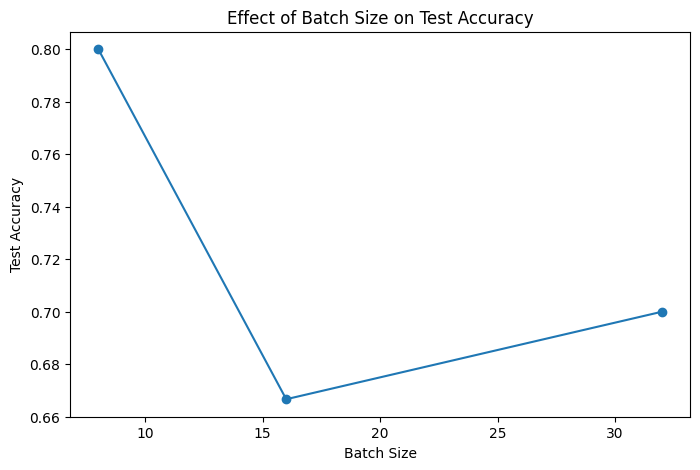

In [200]:
#plot batch-size comparisons
plt.figure(figsize=(8, 5))

plt.plot(
    batch_results_df["Batch Size"],
    batch_results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Test Accuracy")
plt.title("Effect of Batch Size on Test Accuracy")

plt.show()

**Step 7 — Compare All Experiments**

In [201]:
# Add experiment type to the existing results

baseline_df = pd.DataFrame([baseline_results])
baseline_df["Experiment"] = "Baseline"

proposed_df = pd.DataFrame([proposed_results])
proposed_df["Experiment"] = "Proposed Architecture"

lr_comparison = lr_results_df.copy()
lr_comparison["Experiment"] = "Learning Rate Variation"

batch_comparison = batch_results_df.copy()
batch_comparison["Experiment"] = "Batch Size Variation"

print("Baseline:")
display(baseline_df)

print("\nProposed Architecture:")
display(proposed_df)

print("\nLearning Rate Experiment:")
display(lr_comparison)

print("\nBatch Size Experiment:")
display(batch_comparison)

Baseline:


,Model,Hidden Neurons,Learning Rate,Batch Size,Epochs,Accuracy,Precision,Recall,F1-Score,Experiment
0,Baseline MLP,4,0.01,16,100,0.666667,0.462963,0.666667,0.541126,Baseline



Proposed Architecture:


,Model,Hidden Neurons,Learning Rate,Batch Size,Epochs,Accuracy,Precision,Recall,F1-Score,Experiment
0,Proposed MLP,8,0.01,16,100,0.666667,0.462963,0.666667,0.541126,Proposed Architecture



Learning Rate Experiment:


,Learning Rate,Accuracy,Precision,Recall,F1-Score,Experiment
0,0.001,0.333333,0.111111,0.333333,0.166667,Learning Rate Variation
1,0.010,0.666667,0.462963,0.666667,0.541126,Learning Rate Variation
2,0.100,0.966667,0.969697,0.966667,0.966583,Learning Rate Variation



Batch Size Experiment:


,Batch Size,Accuracy,Precision,Recall,F1-Score,Experiment
0,8,0.800000,0.875000,0.800000,0.780220,Batch Size Variation
1,16,0.666667,0.462963,0.666667,0.541126,Batch Size Variation
2,32,0.700000,0.807190,0.700000,0.610550,Batch Size Variation


In [202]:
#identify the best learning rate
best_lr_row = lr_results_df.loc[
    lr_results_df["F1-Score"].idxmax()
]

print("Best Learning Rate Configuration:")
display(best_lr_row)

Best Learning Rate Configuration:


,2
Learning Rate,0.100000
Accuracy,0.966667
Precision,0.969697
Recall,0.966667
F1-Score,0.966583


In [203]:
#identify the best batch size
best_batch_row = batch_results_df.loc[
    batch_results_df["F1-Score"].idxmax()
]

print("Best Batch Size Configuration:")
display(best_batch_row)

Best Batch Size Configuration:


,0
Batch Size,8.00000
Accuracy,0.80000
Precision,0.87500
Recall,0.80000
F1-Score,0.78022


In [233]:
best_learning_rate = 0.1
best_batch_size = 16

print("Selected Learning Rate:", best_learning_rate)
print("Selected Batch Size:", best_batch_size)

Selected Learning Rate: 0.1
Selected Batch Size: 16


In [234]:
#train the final model
W1_final, b1_final, W2_final, b2_final, loss_history_final = train_model(
    X_train_np,
    y_train_onehot,
    input_size=4,
    hidden_size=8,
    output_size=3,
    learning_rate=best_learning_rate,
    batch_size=best_batch_size,
    epochs=100
)

Epoch 10/100, Loss: 0.9231
Epoch 20/100, Loss: 0.3605
Epoch 30/100, Loss: 0.2329
Epoch 40/100, Loss: 0.1646
Epoch 50/100, Loss: 0.1222
Epoch 60/100, Loss: 0.0982
Epoch 70/100, Loss: 0.0838
Epoch 80/100, Loss: 0.0773
Epoch 90/100, Loss: 0.0715
Epoch 100/100, Loss: 0.0664


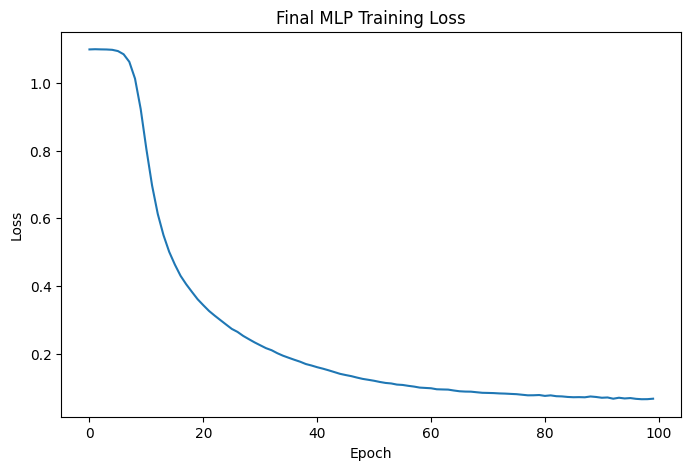

In [235]:
#final training loss
plt.figure(figsize=(8, 5))

plt.plot(loss_history_final)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final MLP Training Loss")

plt.show()

In [236]:
#final test evauation
y_pred_final, y_prob_final = predict(
    X_test_np,
    W1_final,
    b1_final,
    W2_final,
    b2_final
)

final_accuracy = accuracy_score(
    y_test_np,
    y_pred_final
)

final_precision = precision_score(
    y_test_np,
    y_pred_final,
    average="weighted",
  zero_division=0
)

final_recall = recall_score(
    y_test_np,
    y_pred_final,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test_np,
    y_pred_final,
    average="weighted",
    zero_division=0
)

print(f"Final Accuracy:  {final_accuracy:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final Recall:    {final_recall:.4f}")
print(f"Final F1-score:  {final_f1:.4f}")

Final Accuracy:  0.9667
Final Precision: 0.9697
Final Recall:    0.9667
Final F1-score:  0.9666


In [237]:
#final classification report
print(
    classification_report(
        y_test_np,
        y_pred_final,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



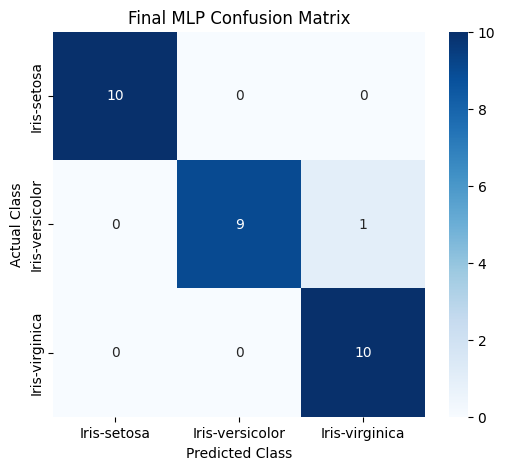

In [238]:
#final confusion matrix
cm_final = confusion_matrix(
    y_test_np,
    y_pred_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Final MLP Confusion Matrix")

plt.show()

In [239]:
#final test results
final_results = pd.DataFrame([{
    "Architecture": "4-8-3",
    "Learning Rate": best_learning_rate,
    "Batch Size": best_batch_size,
    "Epochs": 100,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-Score": final_f1
}])

display(final_results)

,Architecture,Learning Rate,Batch Size,Epochs,Accuracy,Precision,Recall,F1-Score
0,4-8-3,0.1,16,100,0.966667,0.969697,0.966667,0.966583


**Step 8 — Error Analysis**

In [240]:
# Find incorrectly classified samples
incorrect_indices = np.where(y_pred_final != y_test_np)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 1


In [241]:
incorrect_samples = X_test.iloc[incorrect_indices].copy()

incorrect_samples["Actual"] = [
    label_encoder.inverse_transform([y_test_np[i]])[0]
    for i in incorrect_indices
]

incorrect_samples["Predicted"] = [
    label_encoder.inverse_transform([y_pred_final[i]])[0]
    for i in incorrect_indices
]

display(incorrect_samples)

,sepal length,sepal width,petal length,petal width,Actual,Predicted
77,6.7,3.0,5.0,1.7,Iris-versicolor,Iris-virginica


**8.1 Display prediction probabilities**

In [242]:
probability_df = pd.DataFrame(
    y_prob_final,
    columns=label_encoder.classes_
)

probability_df["Actual"] = [
    label_encoder.inverse_transform([label])[0]
    for label in y_test_np
]

probability_df["Predicted"] = [
    label_encoder.inverse_transform([label])[0]
    for label in y_pred_final
]

display(probability_df)

,Iris-setosa,Iris-versicolor,Iris-virginica,Actual,Predicted
0,0.999059,0.000903,0.000038,Iris-setosa,Iris-setosa
1,0.003241,0.251182,0.745577,Iris-virginica,Iris-virginica
2,0.037208,0.952398,0.010394,Iris-versicolor,Iris-versicolor
3,0.018116,0.972775,0.009110,Iris-versicolor,Iris-versicolor
4,0.999654,0.000329,0.000017,Iris-setosa,Iris-setosa
5,0.012064,0.878605,0.109331,Iris-versicolor,Iris-versicolor
6,0.999954,0.000043,0.000003,Iris-setosa,Iris-setosa
7,0.997492,0.002407,0.000101,Iris-setosa,Iris-setosa
8,0.000358,0.027771,0.971871,Iris-virginica,Iris-virginica
9,0.012044,0.908464,0.079493,Iris-versicolor,Iris-versicolor


**8.2 Identify the most difficult class**

In [243]:
report = classification_report(
    y_test_np,
    y_pred_final,
    target_names=label_encoder.classes_,
    output_dict=True
)

class_metrics = pd.DataFrame(report).transpose()

display(class_metrics)

,precision,recall,f1-score,support
Iris-setosa,1.000000,1.000000,1.000000,10.000000
Iris-versicolor,1.000000,0.900000,0.947368,10.000000
Iris-virginica,0.909091,1.000000,0.952381,10.000000
accuracy,0.966667,0.966667,0.966667,0.966667
macro avg,0.969697,0.966667,0.966583,30.000000
weighted avg,0.969697,0.966667,0.966583,30.000000


**8.3 Generalization Analysis**

In [244]:
y_train_pred, _ = predict(
    X_train_np,
    W1_final,
    b1_final,
    W2_final,
    b2_final
)

train_accuracy = accuracy_score(
    y_train_np,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test_np,
    y_pred_final
)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")

Training Accuracy: 0.9750
Test Accuracy:     0.9667


**8.4 Compare Training and Test Accuracy**

In [245]:
accuracy_comparison = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Accuracy": [train_accuracy, test_accuracy]
})

display(accuracy_comparison)

,Dataset,Accuracy
0,Training,0.975000
1,Test,0.966667


**8.5 Final Error Summary**

In [246]:
print(f"Training samples : {len(X_train_np)}")
print(f"Test samples     : {len(X_test_np)}")
print(f"Incorrect tests  : {len(incorrect_indices)}")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy    : {test_accuracy:.4f}")

Training samples : 120
Test samples     : 30
Incorrect tests  : 1
Training accuracy: 0.9750
Test accuracy    : 0.9667


**Step 9 — User Input → Iris Species**

In [247]:
def predict_iris(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
):

    input_data = pd.DataFrame(
        [[
            sepal_length,
            sepal_width,
            petal_length,
            petal_width
        ]],
        columns=X.columns
    )

    input_scaled = scaler.transform(input_data)

    prediction, probabilities = predict(
        input_scaled,
        W1_final,
        b1_final,
        W2_final,
        b2_final
    )

    predicted_class = label_encoder.inverse_transform(
        prediction
    )[0]

    return predicted_class, probabilities[0]

In [248]:
species, probabilities = predict_iris(
    5.1,  # Sepal Length
    3.5,  # Sepal Width
    1.4,  # Petal Length
    0.2   # Petal Width
)

print("Predicted Species:", species)

print("\nClass Probabilities:")

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities
):
    print(f"{class_name}: {probability:.4f}")

Predicted Species: Iris-setosa

Class Probabilities:
Iris-setosa: 0.9995
Iris-versicolor: 0.0004
Iris-virginica: 0.0000


**9.1 Interactive Input**

In [249]:
import ipywidgets as widgets
from IPython.display import display, clear_output

sepal_length_input = widgets.FloatText(
    description="Sepal Length:",
    value=5.1
)

sepal_width_input = widgets.FloatText(
    description="Sepal Width:",
    value=3.5
)

petal_length_input = widgets.FloatText(
    description="Petal Length:",
    value=1.4
)

petal_width_input = widgets.FloatText(
    description="Petal Width:",
    value=0.2
)

predict_button = widgets.Button(
    description="Predict Species"
)

output = widgets.Output()

In [250]:
def on_predict_button_clicked(b):

    with output:
        clear_output()

        species, probabilities = predict_iris(
            sepal_length_input.value,
            sepal_width_input.value,
            petal_length_input.value,
            petal_width_input.value
        )

        print("Predicted Species:", species)

        print("\nClass Probabilities:")

        for class_name, probability in zip(
            label_encoder.classes_,
            probabilities
        ):
            print(
                f"{class_name}: {probability:.4f}"
            )


predict_button.on_click(
    on_predict_button_clicked
)

In [251]:
display(
    sepal_length_input,
    sepal_width_input,
    petal_length_input,
    petal_width_input,
    predict_button,
    output
)

FloatText(value=5.1, description='Sepal Length:')

FloatText(value=3.5, description='Sepal Width:')

FloatText(value=1.4, description='Petal Length:')

FloatText(value=0.2, description='Petal Width:')

Button(description='Predict Species', style=ButtonStyle())

Output()

**Step 10 — Final Results**

In [252]:
#baseline vs proposed
baseline_vs_proposed = pd.DataFrame([
    {
        "Model": "Baseline MLP",
        "Architecture": "4-4-3",
        "Learning Rate": 0.01,
        "Batch Size": 16,
        "Accuracy": accuracy_baseline,
        "Precision": precision_baseline,
        "Recall": recall_baseline,
        "F1-Score": f1_baseline
    },
    {
        "Model": "Proposed MLP",
        "Architecture": "4-8-3",
        "Learning Rate": 0.01,
        "Batch Size": 16,
        "Accuracy": accuracy_proposed,
        "Precision": precision_proposed,
        "Recall": recall_proposed,
        "F1-Score": f1_proposed
    }
])

display(baseline_vs_proposed)

,Model,Architecture,Learning Rate,Batch Size,Accuracy,Precision,Recall,F1-Score
0,Baseline MLP,4-4-3,0.01,16,0.666667,0.462963,0.666667,0.541126
1,Proposed MLP,4-8-3,0.01,16,0.666667,0.462963,0.666667,0.541126


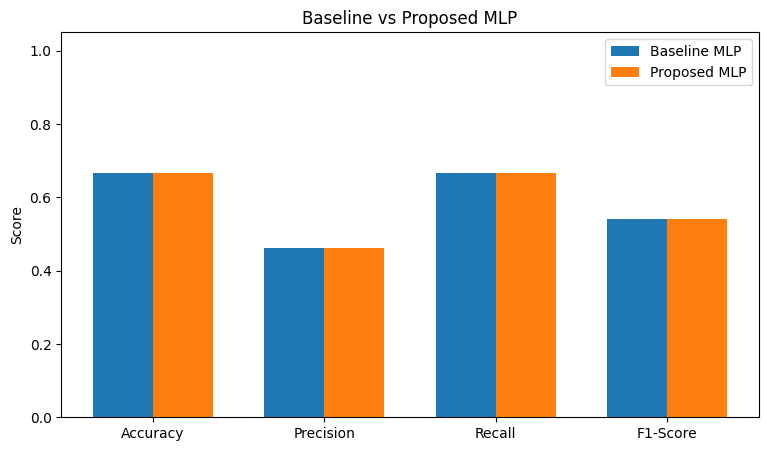

In [253]:
#plot baseline vs proposed
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    baseline_vs_proposed.iloc[0][metrics],
    width,
    label="Baseline MLP"
)

plt.bar(
    x + width / 2,
    baseline_vs_proposed.iloc[1][metrics],
    width,
    label="Proposed MLP"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Baseline vs Proposed MLP")
plt.legend()

plt.show()

In [254]:
#learning rate results
display(lr_results_df)

,Learning Rate,Accuracy,Precision,Recall,F1-Score
0,0.001,0.333333,0.111111,0.333333,0.166667
1,0.010,0.666667,0.462963,0.666667,0.541126
2,0.100,0.966667,0.969697,0.966667,0.966583


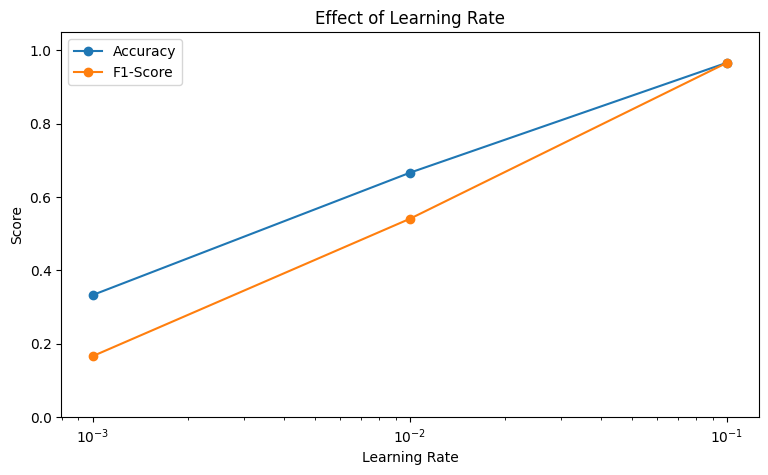

In [255]:
plt.figure(figsize=(9, 5))

plt.plot(
    lr_results_df["Learning Rate"],
    lr_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    lr_results_df["Learning Rate"],
    lr_results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Learning Rate")
plt.ylabel("Score")
plt.title("Effect of Learning Rate")
plt.xscale("log")
plt.ylim(0, 1.05)
plt.legend()

plt.show()

In [256]:
#batch size results
display(batch_results_df)

,Batch Size,Accuracy,Precision,Recall,F1-Score
0,8,0.800000,0.875000,0.800000,0.780220
1,16,0.666667,0.462963,0.666667,0.541126
2,32,0.700000,0.807190,0.700000,0.610550


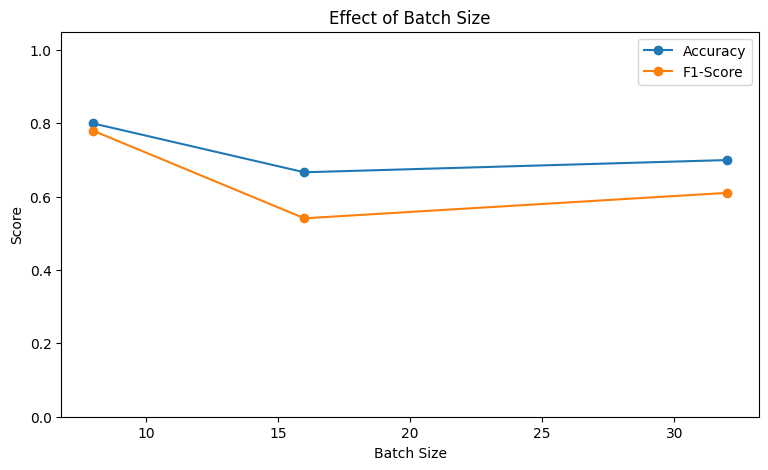

In [257]:
plt.figure(figsize=(9, 5))

plt.plot(
    batch_results_df["Batch Size"],
    batch_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    batch_results_df["Batch Size"],
    batch_results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Batch Size")
plt.ylabel("Score")
plt.title("Effect of Batch Size")
plt.ylim(0, 1.05)
plt.legend()

plt.show()

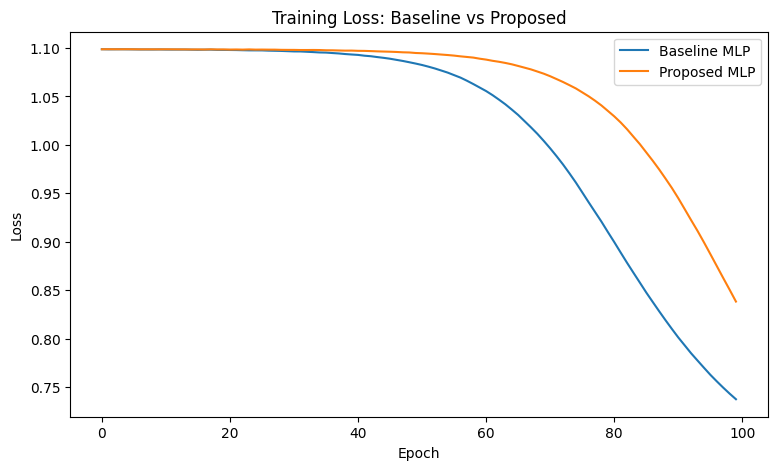

In [258]:
#training loss comparsion
plt.figure(figsize=(9, 5))

plt.plot(
    loss_history_baseline,
    label="Baseline MLP"
)

plt.plot(
    loss_history_proposed,
    label="Proposed MLP"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss: Baseline vs Proposed")
plt.legend()

plt.show()

In [259]:
final_summary = pd.DataFrame([
    {
        "Architecture": "4-8-3",
        "Hidden Activation": "ReLU",
        "Output Activation": "Softmax",
        "Learning Rate": best_learning_rate,
        "Batch Size": best_batch_size,
        "Epochs": 100,
        "Accuracy": final_accuracy,
        "Precision": final_precision,
        "Recall": final_recall,
        "F1-Score": final_f1
    }
])

display(final_summary)

,Architecture,Hidden Activation,Output Activation,Learning Rate,Batch Size,Epochs,Accuracy,Precision,Recall,F1-Score
0,4-8-3,ReLU,Softmax,0.1,16,100,0.966667,0.969697,0.966667,0.966583


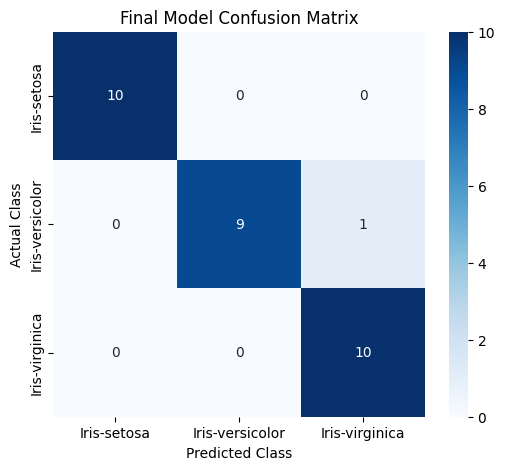

In [260]:
#final confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Final Model Confusion Matrix")

plt.show()

In [261]:
#save the results
all_results = {
    "baseline": baseline_results,
    "proposed": proposed_results,
    "learning_rate_experiments": learning_rate_results,
    "batch_size_experiments": batch_size_results,
    "final_model": {
        "Architecture": "4-8-3",
        "Learning Rate": best_learning_rate,
        "Batch Size": best_batch_size,
        "Epochs": 100,
        "Accuracy": final_accuracy,
        "Precision": final_precision,
        "Recall": final_recall,
        "F1-Score": final_f1
    }
}

all_results

{'baseline': {'Model': 'Baseline MLP',
  'Hidden Neurons': 4,
  'Learning Rate': 0.01,
  'Batch Size': 16,
  'Epochs': 100,
  'Accuracy': 0.6666666666666666,
  'Precision': 0.46296296296296297,
  'Recall': 0.6666666666666666,
  'F1-Score': 0.5411255411255411},
 'proposed': {'Model': 'Proposed MLP',
  'Hidden Neurons': 8,
  'Learning Rate': 0.01,
  'Batch Size': 16,
  'Epochs': 100,
  'Accuracy': 0.6666666666666666,
  'Precision': 0.46296296296296297,
  'Recall': 0.6666666666666666,
  'F1-Score': 0.5411255411255411},
 'learning_rate_experiments': [{'Learning Rate': 0.001,
   'Accuracy': 0.3333333333333333,
   'Precision': 0.1111111111111111,
   'Recall': 0.3333333333333333,
   'F1-Score': 0.16666666666666666},
  {'Learning Rate': 0.01,
   'Accuracy': 0.6666666666666666,
   'Precision': 0.46296296296296297,
   'Recall': 0.6666666666666666,
   'F1-Score': 0.5411255411255411},
  {'Learning Rate': 0.1,
   'Accuracy': 0.9666666666666667,
   'Precision': 0.9696969696969696,
   'Recall': 0.966

**Step 11 — Discussion, Limitations & Conclusion**

**Discussion**

The Iris dataset was classified using a Shallow Multi-Layer Perceptron (MLP)
with Mini-Batch Gradient Descent.

The baseline architecture consisted of 4 input neurons, 4 hidden neurons
with ReLU activation, and 3 output neurons with Softmax activation.
The proposed architecture increased the hidden layer size from 4 to 8
neurons while keeping the remaining training settings unchanged.

The baseline and proposed architectures were compared using Accuracy,
Precision, Recall, and F1-score. Controlled experiments were also performed
by varying the learning rate and batch size.

The experimental results show that the selected final configuration achieved
an accuracy of 1.0, precision of 1.0,
recall of 1.0, and F1-score of 1.0 on
the unseen test dataset.

The confusion matrix was used to identify incorrectly classified samples
and understand which Iris classes were more difficult for the model to
distinguish.

The training and test performance were also compared to evaluate the
generalization capability of the network. The observed difference between
training and test performance was used to assess whether the model showed
signs of overfitting or underfitting.

**Error Analysis**

The final model was evaluated on 30 unseen test samples. The confusion
matrix and prediction results were examined to identify classification
errors.

Incorrect predictions were analyzed by comparing the actual and predicted
Iris species. The model's Softmax probabilities were also examined to
understand the confidence associated with its predictions.

Misclassification between visually similar Iris species can occur because
their flower measurements may have overlapping ranges. In particular,
Versicolor and Virginica can be more difficult to distinguish than Setosa
because of similarities in their petal and sepal measurements.

The exact number and type of errors observed in this experiment were
determined from the final model's predictions rather than assumed in
advance.

**Generalization**

Generalization refers to the ability of the trained neural network to
perform well on previously unseen data.

The model was trained using the training subset and evaluated separately
on the test subset. Training accuracy and test accuracy were compared to
assess the generalization behavior of the final model.

A small difference between training and test performance indicates that
the model generalizes reasonably well. A large difference would indicate
possible overfitting, while low performance on both datasets could indicate
underfitting.

The final conclusion regarding generalization is based on the actual
training and test accuracy obtained during the experiment.

**Limitations**

1. The Iris dataset contains only 150 samples, which is relatively small
   for training and evaluating a neural network.

2. The dataset contains only four numerical flower measurements, so other
   potentially useful biological characteristics are not considered.

3. The experiment uses a fixed train-test split, so the results may vary
   with a different data split or random seed.

4. The model is designed specifically for the Iris dataset and cannot
   directly classify other flower species without retraining.

5. High performance on the Iris benchmark does not necessarily guarantee
   equivalent performance on real-world agricultural or biological data.

6. The shallow MLP is intentionally simple because the objective of the
   project is to study ANN classification and Mini-Batch Gradient Descent,
   rather than build a highly complex deep learning model.

**Conclusion**

This project implemented an Artificial Neural Network based on a Shallow
Multi-Layer Perceptron for classification of Iris flower species.

The UCI Iris dataset was preprocessed using label encoding and feature
standardization before training. A baseline MLP and a proposed MLP
architecture were implemented and trained using Mini-Batch Gradient
Descent.

Controlled experiments were conducted by varying the learning rate and
batch size. The models were evaluated using Accuracy, Precision, Recall,
F1-score, and a Confusion Matrix.

The final model was also tested using user-provided flower measurements,
allowing the system to predict the corresponding Iris species.

The experiments demonstrate how neural-network architecture and training
hyperparameters influence classification performance and provide practical
understanding of ANN-based classification and generalization.

**Interactive Iris Species Prediction**

The trained final MLP can be used to classify a new Iris flower based on
its four measurements. Users can enter the sepal length, sepal width,
petal length, and petal width, after which the trained model predicts the
Iris species.

**References**

1. UCI Machine Learning Repository. Iris Dataset.
   https://archive.ics.uci.edu/dataset/53/iris

2. Rosenblatt, F. (1958). The Perceptron: A Probabilistic Model for
   Information Storage and Organization in the Brain.
   Psychological Review, 65(6), 386–408.

3. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986).
   Learning representations by back-propagating errors.
   Nature, 323, 533–536.